# P2 이론: 딥러닝 프로젝트 유형

**주요 내용**

P1에서는 다층 퍼셉트론의 기본 구조와 훈련 과정을 살펴보았다.

P2에서는 같은 다층 퍼셉트론을 사용하더라도 **해결하려는 문제의 유형**에 따라
타깃의 표현, 출력층, 손실함수, 평가지표가 달라진다는 점을 배운다.

대표적인 세 가지 문제를 다룬다.

- **이진 분류**: 두 클래스 중 하나를 예측
- **다중 클래스 분류**: 여러 클래스 중 하나를 예측
- **회귀**: 연속적인 수치를 예측

또한 훈련셋·검증셋·테스트셋의 역할을 구분하고,
홀드아웃 검증과 교차 검증, 과대적합과 일반화, 규제 방법을 함께 살펴본다.

## 문제 유형에 따라 무엇이 달라질까?

신경망의 앞부분은 비슷하게 구성할 수 있다.
그러나 **모델이 최종적으로 무엇을 예측해야 하는지**에 따라 마지막 부분은 달라진다.

| 문제 유형 | 타깃 | 출력의 의미 | 대표 출력층 | 대표 손실함수 | 대표 평가지표 |
|---|---|---|---|---|---|
| 이진 분류 | 두 클래스 중 하나 | 한 클래스일 가능성 | 1개 유닛 + sigmoid | binary crossentropy | accuracy |
| 다중 클래스 분류 | 여러 클래스 중 하나 | 각 클래스의 확률 | 클래스 수만큼의 유닛 + softmax | sparse categorical crossentropy | accuracy, top-k accuracy |
| 회귀 | 연속적인 수치 | 예측하려는 수치 | 1개 유닛, 활성화 함수 없음 | MSE | RMSE |

> **문제 유형을 먼저 확인한 뒤 출력층, 손실함수, 평가지표를 선택한다.**

### 손실함수와 평가지표는 왜 구분할까?

**손실함수**(loss function)는 모델의 파라미터를 조정하기 위해 사용한다.
훈련 과정에서 손실값을 줄이는 방향으로 가중치가 갱신된다.

**평가지표**(metric)는 모델의 성능을 사람이 이해하기 쉬운 방식으로 확인하기 위해 사용한다.

따라서 같은 문제에서도 손실함수와 평가지표가 서로 다를 수 있다.
예를 들어 회귀에서는 MSE를 손실함수로 사용하면서 RMSE를 평가지표로 사용할 수 있다.

## 이진 분류: 두 클래스 중 하나를 예측하기

IMDB 영화 후기 문제에서는 각 후기를 **긍정** 또는 **부정**으로 분류한다.

타깃은 두 값 중 하나다.

- `0`: 부정
- `1`: 긍정

이처럼 각 입력이 두 개의 서로 배타적인 클래스 중 하나에 속하는 문제를
**이진 분류**(binary classification)라고 한다.

### 하나의 출력값으로 두 클래스를 표현할 수 있다

이진 분류에서는 출력층에 하나의 유닛을 두고
**시그모이드**(sigmoid) 활성화 함수를 사용할 수 있다.

시그모이드는 임의의 실수를 0과 1 사이의 값으로 변환한다.

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

따라서 출력값을 한 클래스에 속할 가능성으로 해석할 수 있다.

예를 들어 출력이 `0.92`라면 긍정일 가능성이 높다고 판단하고,
`0.08`이라면 부정일 가능성이 높다고 판단할 수 있다.

### 이진 교차엔트로피

이진 분류에서는 **이진 교차엔트로피**(binary crossentropy)를 대표적인 손실함수로 사용한다.

한 샘플에 대한 손실은 다음과 같이 나타낼 수 있다.

$$
L=-\left[y\log(p)+(1-y)\log(1-p)\right]
$$

여기서

- $y$는 실제 타깃($0$ 또는 $1$)
- $p$는 모델이 예측한 확률

이다.

정답이 1인데 $p$가 1에 가까우면 손실이 작아지고,
정답이 1인데 $p$가 0에 가까우면 손실이 커진다.

즉 **정답에 높은 확률을 부여하도록 모델을 훈련시키는 손실함수**라고 이해하면 된다.

### 은닉층의 유닛 수는 정답이 아니다

IMDB 실습에서는 두 은닉층에 각각 16개의 유닛을 사용한다.

두 은닉층에서 같은 수의 유닛을 사용한 것은
**모델 구조를 단순하게 유지하기 위한 설계 선택**이다.
각 층의 유닛 수는 서로 다르게 정할 수도 있다.

유닛 수가 많아지면 더 복잡한 관계를 표현할 수 있지만,
계산량이 증가하고 과대적합이 더 쉽게 나타날 수도 있다.

따라서 층의 수와 유닛 수는 검증 성능을 보면서 조정하는 **하이퍼파라미터**다.

### 훈련 성능만 좋아지면 충분할까?

아니다.

훈련 데이터에서 손실이 계속 감소하더라도,
새로운 데이터에 대한 성능이 함께 좋아진다는 보장은 없다.

다음 그래프는 IMDB 모델의 훈련 손실과 검증 손실을 함께 보여준다.

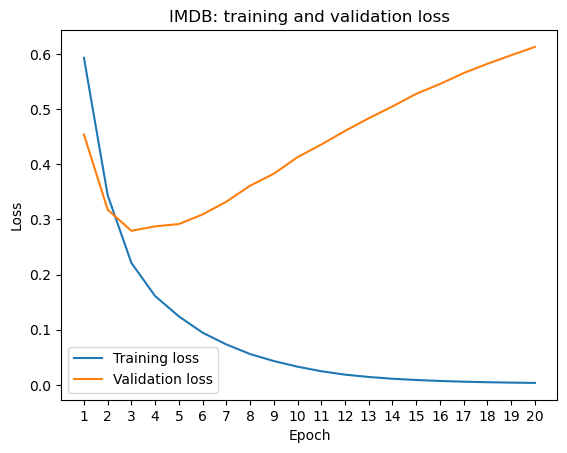

*P2 실습에서 생성한 IMDB 이진 분류의 훈련·검증 손실 곡선*

훈련 손실은 계속 감소하지만 어느 시점부터 검증 손실이 다시 증가한다면,
모델이 훈련 데이터에는 점점 더 잘 맞지만 새로운 데이터에는 덜 잘 맞기 시작한 것이다.

이 현상을 **과대적합**(overfitting)이라고 한다.

> **훈련 성능과 검증 성능을 함께 보아야 모델의 일반화 상태를 판단할 수 있다.**

## 다중 클래스 분류: 여러 클래스 중 하나를 예측하기

Reuters 뉴스 기사 문제에서는 각 기사를 46개의 주제 중 하나로 분류한다.

각 샘플이 여러 클래스 중 **정확히 하나의 클래스**에 속하므로
이 문제는 **단일 레이블 다중 클래스 분류**(single-label multiclass classification)다.

### 출력층에는 클래스 수만큼의 유닛이 필요하다

46개의 클래스를 구분하려면 출력층도 46개의 값을 출력한다.

각 출력값은 해당 클래스에 대한 점수이고,
**소프트맥스**(softmax)를 사용하면 이 점수들을 확률 분포로 변환할 수 있다.

클래스 $i$에 대한 소프트맥스 출력은 다음과 같다.

$$
p_i=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

각 $p_i$는 0과 1 사이이고,

$$
\sum_i p_i=1
$$

이 된다.

따라서 46개의 출력값을 **46개 클래스에 대한 확률 분포**로 해석할 수 있다.

### 타깃을 정수 클래스 번호로 사용할 수 있다

Reuters의 타깃은 `0`부터 `45`까지의 정수로 표현할 수 있다.

예를 들어 타깃 `12`는 연속적인 수치 12를 뜻하는 것이 아니라
**12번 클래스**라는 뜻이다.

이처럼 타깃을 정수 클래스 번호로 사용하는 경우
**sparse categorical crossentropy**를 사용할 수 있다.

반대로 타깃을 one-hot 벡터로 바꾸어 사용한다면
categorical crossentropy를 사용할 수 있다.

> **같은 다중 클래스 분류라도 타깃을 어떻게 표현하는지에 따라 손실함수의 형태가 달라질 수 있다.**

### 왜 은닉층을 64유닛으로 넓혔을까?

IMDB에서는 두 클래스를 구분했지만 Reuters에서는 46개 클래스를 구분해야 한다.

은닉층이 지나치게 작으면 앞선 층에서 필요한 정보가 줄어들어
뒤쪽 층이 다시 복원할 수 없는 **정보 병목**(information bottleneck)이 생길 수 있다.

그래서 실습에서는 IMDB의 16유닛보다 넓은 64유닛을 사용한다.

다만 `64`가 정답이라는 뜻은 아니다.
32, 64, 128처럼 다른 크기를 사용할 수 있으며,
적절한 크기는 검증 결과를 통해 판단해야 한다.

### Accuracy와 Top-3 accuracy

일반적인 accuracy는 **가장 높은 확률을 받은 클래스 하나가 정답인지** 확인한다.

그러나 클래스 수가 많으면 정답 클래스를 두 번째나 세 번째로 높게 예측했더라도
일반 accuracy에서는 완전히 틀린 것으로 계산된다.

**Top-3 accuracy**는 모델이 예측한 확률이 높은 **상위 3개 클래스 안에 정답 클래스가 포함된 비율**이다.

> 클래스 수가 많은 경우 일반 accuracy만으로는 모델의 예측 정보를 충분히 반영하지 못할 수 있으므로, Top-3 accuracy를 보조적으로 함께 볼 수 있다.

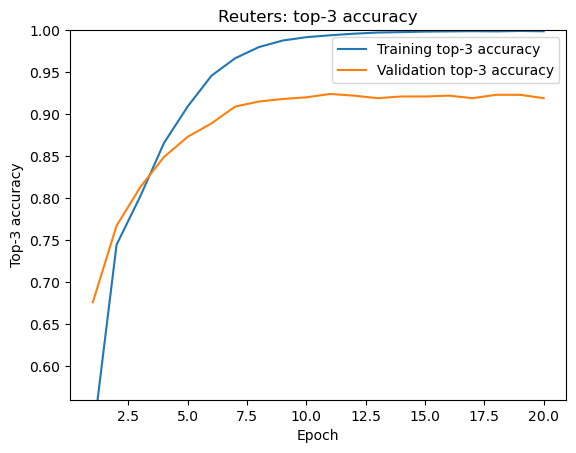

*P2 실습에서 생성한 Reuters 다중 클래스 분류의 Top-3 accuracy 변화*

Top-3 accuracy가 일반 accuracy보다 높은 것은 자연스럽다.
정답을 정확히 1순위로 맞힌 경우뿐 아니라 2순위나 3순위에 포함한 경우도 성공으로 보기 때문이다.

따라서 두 지표는 경쟁 관계가 아니라 **서로 다른 질문에 답하는 지표**다.

- Accuracy: 정답을 가장 높은 확률의 클래스로 선택했는가?
- Top-3 accuracy: 정답이 상위 세 후보 안에 들어왔는가?

## 회귀: 연속적인 수치를 예측하기

California Housing 문제에서는 지역의 여러 특성을 이용하여
**중위 주택가격**이라는 연속적인 값을 예측한다.

분류와 가장 큰 차이는 타깃이 클래스 번호가 아니라
**연속적인 수치**라는 점이다.

이와 같은 문제를 **회귀**(regression)라고 한다.

### 회귀 출력층에는 왜 활성화 함수를 사용하지 않을까?

주택가격은 0과 1 사이의 확률도 아니고,
몇 개의 클래스 중 하나도 아니다.

따라서 출력값을 특정 범위로 제한할 필요가 없다.

실습에서는 하나의 수치를 예측하므로 출력층에 하나의 유닛을 사용하고,
시그모이드나 소프트맥스 같은 활성화 함수를 지정하지 않는다.

> **분류의 출력층은 확률이나 클래스와 연결되지만, 회귀의 출력층은 예측하려는 수치 자체를 출력한다.**

### MSE와 RMSE

회귀에서는 예측값 $\hat{y}$와 실제값 $y$의 차이를 측정해야 한다.

**평균제곱오차**(mean squared error, MSE)는

$$
\mathrm{MSE}
=
\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

로 정의된다.

오차를 제곱하기 때문에 큰 오차에 더 큰 영향을 받는다.

실습에서는 MSE를 손실함수로 사용하고,
평가지표로는 **평균제곱근오차**(root mean squared error, RMSE)를 사용한다.

$$
\mathrm{RMSE}
=
\sqrt{\mathrm{MSE}}
$$

RMSE는 타깃과 같은 단위를 가지므로 결과를 해석하기가 더 쉽다.

### California Housing의 단위

실습에서 사용하는 California Housing 데이터에서는

- `MedInc`: 가구 중위소득, **1만 달러 단위**
- 타깃: 지역의 중위 주택가격, **10만 달러 단위**

로 표현된다.

예를 들어

- `MedInc = 8.3252`는 약 83,252달러의 중위소득
- 타깃 `2.5`는 약 250,000달러의 중위 주택가격

을 의미한다.

평가지표를 해석할 때는 이 단위를 함께 확인해야 한다.

### 입력 특성을 왜 표준화할까?

California Housing의 입력 특성들은 서로 다른 단위와 범위를 가진다.

예를 들어 중위소득, 위도, 경도, 평균 방 수는 숫자의 크기가 서로 크게 다를 수 있다.

이 상태로 신경망을 훈련하면 일부 특성의 큰 수치 범위가 최적화 과정에 불필요한 영향을 줄 수 있다.

그래서 각 특성에 대해

$$
x'=\frac{x-\mu}{\sigma}
$$

와 같이 평균을 빼고 표준편차로 나누는 **표준화**(standardization)를 사용한다.

중요한 원칙은 다음과 같다.

> **표준화에 사용하는 평균과 표준편차는 훈련 데이터에서만 계산한다.**

검증셋이나 테스트셋의 정보를 이용해 평균과 표준편차를 계산하면
훈련 과정이 아직 보지 말아야 할 데이터의 정보를 미리 사용하는 셈이 된다.

이런 현상을 **데이터 누수**(data leakage)라고 한다.

따라서 훈련 데이터에서 계산한 변환 기준을
검증 데이터와 테스트 데이터에 그대로 적용해야 한다.

### 회귀에서도 훈련 성능과 검증 성능을 함께 본다

분류에서는 loss와 accuracy를 살펴보았다.
회귀에서는 MSE와 RMSE를 이용해 같은 원리를 확인할 수 있다.

다음 그래프는 훈련 RMSE와 검증 RMSE의 변화를 보여준다.

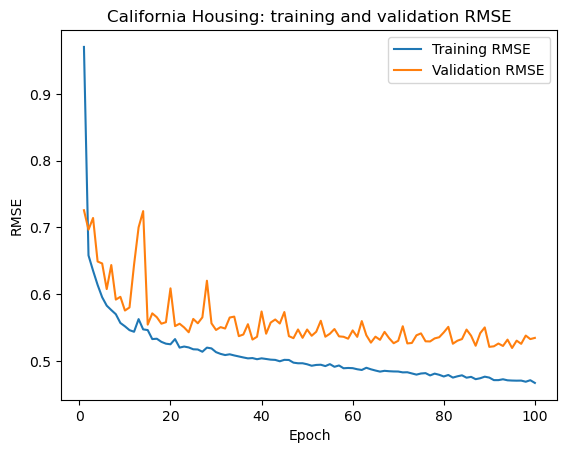

*P2 실습에서 생성한 California Housing 회귀의 훈련·검증 RMSE 곡선*

훈련 RMSE만 계속 감소하고 검증 RMSE가 더 이상 감소하지 않거나 다시 증가한다면
회귀 문제에서도 과대적합이 나타나고 있다고 볼 수 있다.

즉 **과대적합과 일반화는 분류에만 해당하는 개념이 아니다.**
문제 유형과 관계없이 훈련 데이터와 새로운 데이터 사이의 성능 차이를 확인해야 한다.

## 모델 평가: 훈련셋, 검증셋, 테스트셋

세 데이터셋의 역할을 구분하는 것은 매우 중요하다.

| 데이터 | 역할 |
|---|---|
| 훈련셋 | 모델의 파라미터를 학습 |
| 검증셋 | 모델 구조, 하이퍼파라미터, 훈련 시점 등을 판단 |
| 테스트셋 | 모든 선택이 끝난 뒤 최종 성능을 평가 |

테스트셋은 모델 선택 과정에서 반복적으로 사용하지 않는다.

테스트 결과를 보고 모델을 계속 수정하면
테스트셋도 사실상 검증셋처럼 사용하게 되기 때문이다.

### 홀드아웃 검증

앞의 이진 분류, 다중 클래스 분류, 회귀 실습에서는
훈련 데이터의 일부를 따로 떼어 검증셋으로 사용하는
**홀드아웃 검증**(hold-out validation)을 사용한다.

구조는 단순하다.

> **훈련 데이터 → 훈련셋 + 검증셋**

모델은 훈련셋으로 학습하고,
검증셋으로 일반화 성능을 관찰한다.

데이터가 충분히 많을 때는 간단하고 효율적인 방법이다.

### K-fold 교차 검증

하나의 검증셋에만 의존하면
어떤 샘플이 검증셋에 들어갔는지에 따라 평가 결과가 달라질 수 있다.

**K-fold 교차 검증**(K-fold cross-validation)은
훈련 데이터를 $K$개의 부분으로 나누고,
각 부분을 한 번씩 검증셋으로 사용한다.

3겹 교차 검증이라면 다음과 같이 진행된다.

1. fold 1을 검증, fold 2·3을 훈련
2. fold 2를 검증, fold 1·3을 훈련
3. fold 3을 검증, fold 1·2를 훈련
4. 세 검증 점수를 평균

> **교차 검증은 회귀 전용 방법이 아니다. 분류와 회귀 모두에서 사용할 수 있는 일반적인 모델 평가 방법이다.**

### 언제 교차 검증이 유용할까?

특히 데이터가 많지 않아 하나의 검증셋을 떼어내기 부담스럽거나,
검증셋의 구성에 따라 평가 결과가 크게 달라질 수 있을 때 유용하다.

다만 $K$개의 모델을 반복해서 훈련해야 하므로
단순한 홀드아웃보다 계산 비용이 크다.

분류에서는 각 fold에 클래스 비율이 크게 달라지지 않도록
**층화 교차 검증**(stratified cross-validation)을 사용할 수도 있다.

## 일반화: 훈련 데이터를 잘 맞추는 것과 새로운 데이터를 잘 맞추는 것은 다르다

딥러닝 모델의 목적은 훈련 데이터를 외우는 것이 아니라
**보지 못한 새로운 데이터에서도 좋은 성능을 내는 것**이다.

이를 **일반화**(generalization)라고 한다.

모델이 너무 단순하면 훈련 데이터의 관계조차 충분히 학습하지 못하는
**과소적합**(underfitting)이 나타날 수 있다.

반대로 모델이 훈련 데이터에 지나치게 맞춰지면
**과대적합**이 나타날 수 있다.

### 최적화와 일반화는 같은 목표가 아니다

훈련 과정에서 optimizer가 직접 줄이는 것은 **훈련 손실**이다.

하지만 우리가 실제로 원하는 것은
새로운 데이터에서 낮은 손실과 좋은 성능을 얻는 것이다.

따라서

> **훈련 손실 감소 = 일반화 성능 향상**

이라고 생각하면 안 된다.

검증 성능을 함께 관찰해야 하는 이유가 바로 여기에 있다.

## 일반화 성능을 개선하는 방법

P2 실습에서는 대표적인 방법으로 다음을 다룬다.

- **L2 가중치 규제**
- **드롭아웃**
- **조기 종료**

세 방법은 모두 과대적합에 대응하지만 작동 방식은 서로 다르다.

### L2 가중치 규제

L2 가중치 규제는 큰 가중치에 추가 비용을 부과한다.

기본 손실함수가 $L$이라면 다음과 같이 생각할 수 있다.

$$
L_{\mathrm{regularized}}
=
L
+
\lambda\sum_i w_i^2
$$

$\lambda$가 클수록 큰 가중치에 더 강한 패널티를 준다.

모델이 일부 입력에 지나치게 큰 가중치를 두는 것을 억제하여
보다 완만한 표현을 학습하도록 유도하는 방법이다.

L2 규제를 적용하면 규제 항이 손실에 추가되므로
훈련 손실 자체가 기본 모델보다 높게 나타날 수도 있다.

따라서 **훈련 손실이 더 낮은가**만 비교해서는 안 된다.

중요한 질문은 다음과 같다.

> **검증 손실의 증가가 늦어지거나 완만해졌는가?**

### 드롭아웃

**드롭아웃**(dropout)은 훈련 중에 일부 유닛의 출력을 무작위로 0으로 만든다.

매 훈련 스텝마다 다른 일부 연결이 일시적으로 사용되지 않으므로
모델이 특정 유닛이나 연결에 지나치게 의존하는 것을 줄일 수 있다.

중요한 점은 드롭아웃이 **훈련 중에만 적용**된다는 것이다.
평가나 예측 단계에서는 모든 유닛을 사용한다.

### 조기 종료

훈련을 오래 계속하면 훈련 손실은 더 줄어들 수 있지만
검증 손실은 이미 나빠지고 있을 수 있다.

**조기 종료**(early stopping)는
검증 성능이 더 이상 개선되지 않을 때 훈련을 멈춘다.

즉 모델 구조 자체를 바꾸는 규제 방법과 달리,
**언제 훈련을 종료할지**를 결정하여 과대적합을 줄이는 방법이다.

### 세 모델의 검증 손실을 비교해보자

다음 그래프는 IMDB 문제에서 기본 모델,
L2 규제를 적용한 모델,
드롭아웃과 조기 종료를 적용한 모델의 검증 손실을 비교한다.

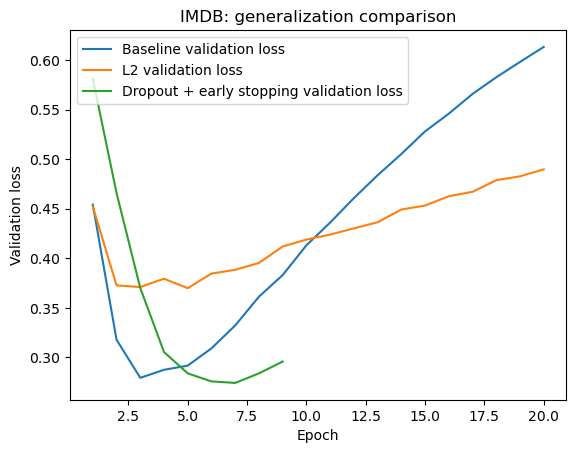

*P2 실습에서 생성한 기본 모델, L2 규제 모델, 드롭아웃 모델의 검증 손실 비교*

이 그래프에서 중요한 것은 단순히 어느 선이 가장 낮은지만 보는 것이 아니다.

- 과대적합이 시작되는 시점이 달라졌는가?
- 검증 손실이 증가하는 속도가 달라졌는가?
- 규제를 적용했을 때 훈련 성능과 검증 성능의 차이가 어떻게 변했는가?

를 함께 살펴봐야 한다.

> **규제의 목적은 훈련 데이터를 더 잘 맞추는 것이 아니라 새로운 데이터에 더 잘 일반화하도록 만드는 것이다.**

## 훈련 과정을 관리하는 방법

딥러닝에서는 모델 구조와 손실함수뿐 아니라
훈련 과정 자체를 관리하는 것도 중요하다.

P2 실습에서 사용하는 대표적인 방법은 다음과 같다.

| 방법 | 역할 |
|---|---|
| EarlyStopping | 검증 성능이 더 이상 좋아지지 않으면 훈련 종료 |
| ModelCheckpoint | 가장 좋은 시점의 모델을 저장 |
| ReduceLROnPlateau | 검증 성능이 정체되면 학습률을 낮춤 |

이 방법들은 모두 검증 성능을 관찰하지만 역할은 서로 다르다.

**ModelCheckpoint**는 그 자체로 모델의 일반화 성능을 개선하는 규제 방법은 아니다.
좋은 시점의 모델을 잃지 않도록 저장하는 훈련 관리 방법이다.

**ReduceLROnPlateau**는 학습이 정체되었을 때 더 작은 학습률로
세밀하게 파라미터를 조정할 기회를 준다.

따라서 콜백을 사용할 때도
“무엇을 관찰하고, 어떤 동작을 수행하는가”를 구분해서 이해해야 한다.

## Keras와 PyTorch: 원리는 같고 표현 방식이 다르다

P2에서 중요한 것은 프레임워크별 문법 자체보다
**문제 유형에 따라 출력과 손실이 어떻게 연결되는지** 이해하는 것이다.

| 문제 | Keras에서 흔한 출력 | PyTorch에서 흔한 출력 | 손실의 핵심 |
|---|---|---|---|
| 이진 분류 | sigmoid 확률 | logits | binary crossentropy |
| 다중 클래스 분류 | softmax 확률 | logits | crossentropy |
| 회귀 | 연속적인 수치 | 연속적인 수치 | MSE 등 |

PyTorch에서는 손실함수가 logits를 직접 입력으로 받는 경우가 많기 때문에
모델의 마지막 층에 sigmoid나 softmax를 명시적으로 넣지 않는 경우가 많다.

### Logit이란?

활성화 함수를 적용하기 전의 출력값을 **logit**이라고 한다.

이진 분류에서는 logit에 sigmoid를 적용하면 확률이 되고,
다중 클래스 분류에서는 여러 logit에 softmax를 적용하면 확률 분포가 된다.

따라서

> **Keras에서는 모델이 확률까지 출력하도록 구성할 수 있고, PyTorch에서는 모델이 logits를 출력하고 손실함수가 확률 변환까지 함께 처리하는 방식이 흔하다.**

두 방식의 핵심 원리는 같다.

## 세 문제를 다시 비교해보자

| 구분 | IMDB | Reuters | California Housing |
|---|---|---|---|
| 문제 유형 | 이진 분류 | 다중 클래스 분류 | 회귀 |
| 타깃 | 0 또는 1 | 0~45의 클래스 번호 | 연속적인 주택가격 |
| 출력의 의미 | 긍정일 가능성 | 46개 클래스의 확률 | 예측 주택가격 |
| 출력층 | 1 + sigmoid | 46 + softmax | 1, 활성화 없음 |
| 손실함수 | binary crossentropy | sparse categorical crossentropy | MSE |
| 대표 평가지표 | accuracy | accuracy, top-3 accuracy | RMSE |

세 모델은 모두 다층 퍼셉트론을 사용하지만,
**문제 유형에 따라 마지막 출력과 손실의 의미가 달라진다.**

## 핵심 정리

P2에서 가장 중요한 흐름은 다음과 같다.

> **문제 유형 확인 → 타깃 표현 확인 → 출력층 선택 → 손실함수 선택 → 평가지표 선택 → 훈련·검증 → 일반화 판단**

기억해야 할 핵심은 다음과 같다.

- 이진 분류는 하나의 sigmoid 출력으로 표현할 수 있다.
- 다중 클래스 분류는 클래스 수만큼의 출력을 사용하고 softmax로 확률 분포를 만들 수 있다.
- 회귀는 연속적인 수치를 직접 출력하며 출력층에 활성화 함수를 사용하지 않을 수 있다.
- 손실함수는 모델을 훈련하기 위한 기준이고, 평가지표는 성능을 해석하기 위한 기준이다.
- 검증셋은 모델 선택 과정에 사용하고 테스트셋은 최종 평가에 사용한다.
- 교차 검증은 분류와 회귀 모두에 사용할 수 있는 일반적인 평가 방법이다.
- 훈련 성능이 좋아지는 것만으로 일반화 성능이 좋아진다고 판단할 수 없다.
- L2 규제, 드롭아웃, 조기 종료는 과대적합에 대응하는 서로 다른 방법이다.

## 확인 문제

1. 이진 분류에서 출력층에 하나의 sigmoid 유닛을 사용할 수 있는 이유는 무엇인가?
2. Reuters처럼 클래스가 많은 문제에서 은닉층이 지나치게 작으면 어떤 문제가 생길 수 있는가?
3. Accuracy와 Top-3 accuracy는 각각 어떤 질문에 답하는 지표인가?
4. 회귀 출력층에 활성화 함수를 사용하지 않는 이유는 무엇인가?
5. MSE와 RMSE의 차이는 무엇이며, RMSE가 해석에 편리한 이유는 무엇인가?
6. 표준화 기준을 검증셋이나 테스트셋에서 계산하면 왜 문제가 되는가?
7. 홀드아웃 검증과 K-fold 교차 검증의 차이를 설명하라.
8. 교차 검증이 회귀 문제에만 사용하는 방법이 아닌 이유를 설명하라.
9. 과대적합이 발생하면 훈련 손실과 검증 손실은 일반적으로 어떻게 달라지는가?
10. L2 가중치 규제, 드롭아웃, 조기 종료가 과대적합에 대응하는 방식의 차이를 설명하라.